# Oetztal quick maps

- 2024 water map from Sentinel-2 NDWI
- terrain map from COPERNICUS_30 DEM

In [4]:
from pathlib import Path

import matplotlib
%matplotlib widget
import matplotlib.pyplot as plt

import numpy as np
import openeo
import xarray as xr
from IPython.display import Image, display


ROOT = Path("/home/vsilv/.nextcloud/src/cassini/11th_cassini_hackathon/python_analysis")
DATA_DIR = ROOT / "data" / "oetztal"
FIG_DIR = ROOT / "figures"
DATA_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

CENTER_LAT = 46.83
CENTER_LON = 10.78
HALF_SIZE_DEG = 0.08
BBOX = {
    "west": CENTER_LON - HALF_SIZE_DEG,
    "east": CENTER_LON + HALF_SIZE_DEG,
    "south": CENTER_LAT - HALF_SIZE_DEG,
    "north": CENTER_LAT + HALF_SIZE_DEG,
    "crs": "EPSG:4326",
}

print("BBox:", BBOX)

BBox: {'west': 10.7, 'east': 10.86, 'south': 46.75, 'north': 46.91, 'crs': 'EPSG:4326'}


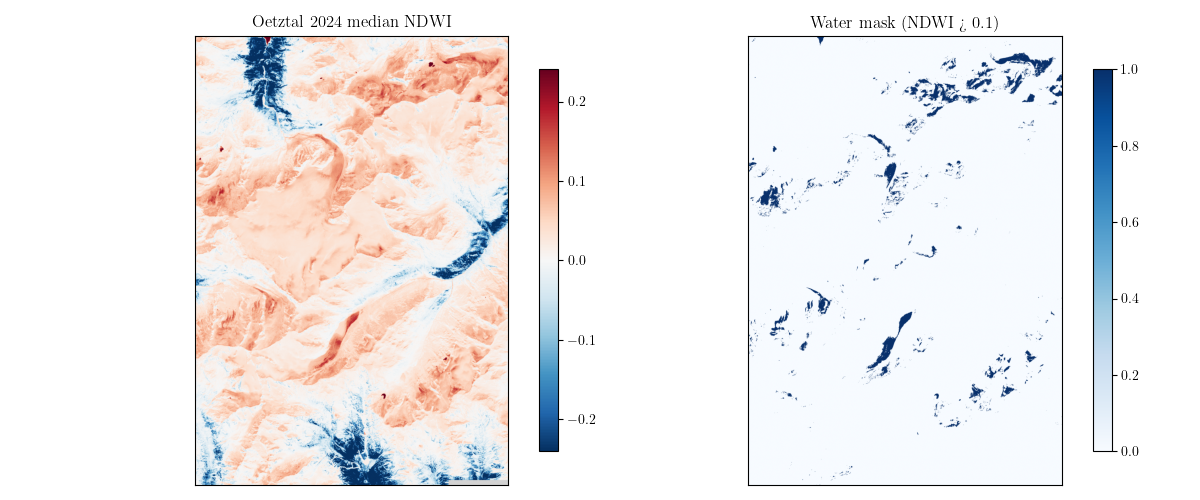

In [5]:
# Water map (S2 2024 NDWI)
s2_file = DATA_DIR / "oetztal_s2_2024-01-01_2024-12-31.nc"
if not s2_file.exists():
    raise RuntimeError(f"Missing file: {s2_file}. Download S2 yearly chunks first.")

ds = xr.open_dataset(s2_file, engine="netcdf4")
tname = "t" if "t" in ds.dims else "time"

valid = xr.zeros_like(ds["SCL"], dtype=bool)
for v in [2, 4, 5, 6, 7, 11]:  # dark area, vegetation, bare soil, water, unclassified, snow/ice
    valid = valid | (ds["SCL"] == v)

ndwi_raw = ((ds["B03"].astype("float32") - ds["B08"].astype("float32")) /
            (ds["B03"].astype("float32") + ds["B08"].astype("float32")))
ndwi_masked = ndwi_raw.where(valid)
ndwi_2d = ndwi_masked.median(dim=tname, skipna=True)

finite_ratio = float(np.isfinite(ndwi_2d.values).mean())
if finite_ratio < 0.01:
    print(f"Masked NDWI has too few finite pixels ({finite_ratio:.4f}), falling back to unmasked median.")
    ndwi_2d = ndwi_raw.median(dim=tname, skipna=True)

water = (ndwi_2d > 0.1).astype(np.uint8)

vals = ndwi_2d.values
good = vals[np.isfinite(vals)]
if good.size > 0:
    lo, hi = np.nanpercentile(good, [2, 98])
    vmax = float(max(abs(lo), abs(hi)))
    if vmax == 0:
        vmax = 1.0
    vmin = -vmax
else:
    vmin, vmax = -1.0, 1.0

fig, ax = plt.subplots(1, 2, figsize=(12, 5), facecolor="white")
cmap = plt.get_cmap("RdBu_r").copy()
cmap.set_bad("lightgray")
im0 = ax[0].imshow(ndwi_2d, cmap=cmap, vmin=vmin, vmax=vmax)
ax[0].set_title("Oetztal 2024 median NDWI")
ax[0].set_xticks([]); ax[0].set_yticks([])
plt.colorbar(im0, ax=ax[0], shrink=0.85)

im1 = ax[1].imshow(water, cmap="Blues", vmin=0, vmax=1)
ax[1].set_title("Water mask (NDWI > 0.1)")
ax[1].set_xticks([]); ax[1].set_yticks([])
plt.colorbar(im1, ax=ax[1], shrink=0.85)

plt.tight_layout()
plt.show()

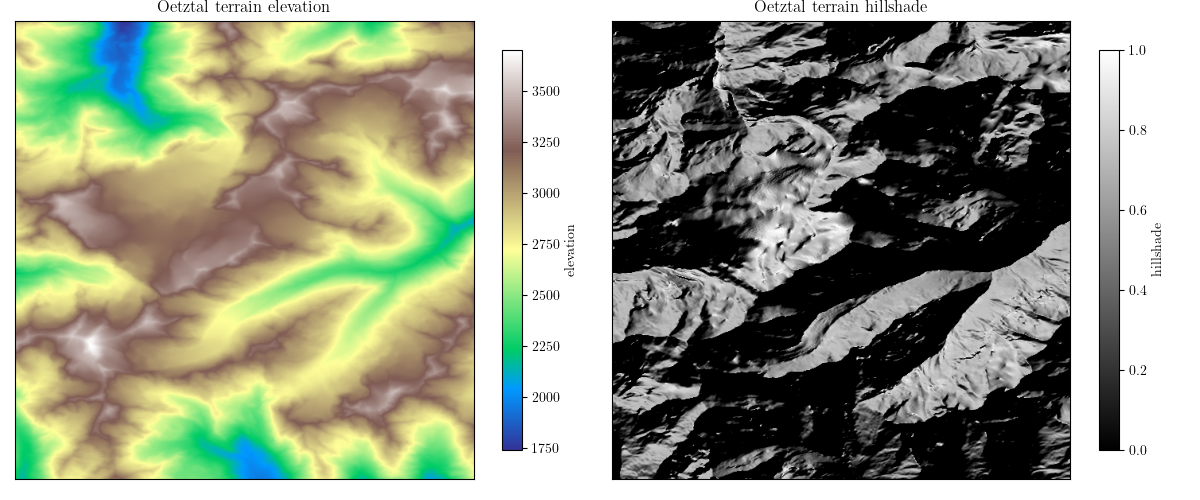

In [6]:
# Terrain map (COPERNICUS_30 DEM)
dem_file = DATA_DIR / "oetztal_dem_copernicus30.nc"

if not dem_file.exists():
    print("Downloading DEM from openEO (COPERNICUS_30)...")
    conn = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()
    # COPERNICUS_30 has temporal coverage roughly 2010-2015 on this backend
    dem_cube = conn.load_collection(
        "COPERNICUS_30",
        spatial_extent=BBOX,
        temporal_extent=["2012-01-01", "2012-12-31"],
        bands=["DEM"],
    )
    dem_cube.download(str(dem_file))

dem_ds = xr.open_dataset(dem_file, engine="netcdf4")

# Pick first 2D variable (DEM values)
dem_var = None
for name, da in dem_ds.data_vars.items():
    if len(da.dims) >= 2:
        dem_var = name
        break
if dem_var is None:
    raise RuntimeError(f"Could not find 2D DEM variable in {dem_file}. vars={list(dem_ds.data_vars)}")

dem = dem_ds[dem_var].astype("float32")
for d in list(dem.dims):
    if d not in ["x", "y", "lon", "lat", "longitude", "latitude"]:
        dem = dem.isel({d: 0})

arr = dem.values

# Hillshade
dy, dx = np.gradient(arr)
slope = np.pi / 2.0 - np.arctan(np.sqrt(dx * dx + dy * dy))
aspect = np.arctan2(-dx, dy)
azimuth = np.deg2rad(315.0)
altitude = np.deg2rad(45.0)
hillshade = np.sin(altitude) * np.sin(slope) + np.cos(altitude) * np.cos(slope) * np.cos(azimuth - aspect)
hillshade = np.clip(hillshade, 0, 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 5), facecolor="white")
im0 = ax[0].imshow(arr, cmap="terrain")
ax[0].set_title("Oetztal terrain elevation")
ax[0].set_xticks([]); ax[0].set_yticks([])
plt.colorbar(im0, ax=ax[0], shrink=0.85, label="elevation")

im1 = ax[1].imshow(hillshade, cmap="gray", vmin=0, vmax=1)
ax[1].set_title("Oetztal terrain hillshade")
ax[1].set_xticks([]); ax[1].set_yticks([])
plt.colorbar(im1, ax=ax[1], shrink=0.85, label="hillshade")

plt.tight_layout()
plt.show()